In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import healpy as hp
import pandas as pd

import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
import time



In [2]:
# Baseline Survey
baseline_file = "baseline_v5.3.2_10yrs.db" #get_baseline()
runName = os.path.split(baseline_file)[-1].replace('.db', '')
outDir = 'sn'
resultsDb = maf.db.ResultsDb(out_dir=outDir)

In [3]:
sne_nside = 64
sn_summary = [maf.MedianMetric(), maf.MeanMetric(),
              maf.SumMetric(metric_name='Total detected')]
slicer = maf.HealpixSlicer(nside=sne_nside, use_cache=False)
#slicer = maf.HealpixSubsetSlicer(nside=16, hpid=[890], useCache=False)
#slicer = maf.HealpixSubsetSlicer(nside=16, hpid=[889], useCache=False)

metric = maf.metrics.SNSLMetric()
bundle = maf.MetricBundle(
        metric,
        slicer,
        "",
        run_name=runName,
        summary_metrics=maf.metrics.SumMetric(metric_name="Total detected", nansum=True),
    )

bg = maf.MetricBundleGroup({'sn': bundle}, baseline_file, outDir, resultsDb)

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/maps/dust_map.py:46: UserWarning: Slicer value of nside 64 different from map value 128, using slicer value
  warnings.warn(


runtime= 224.00945520401 s


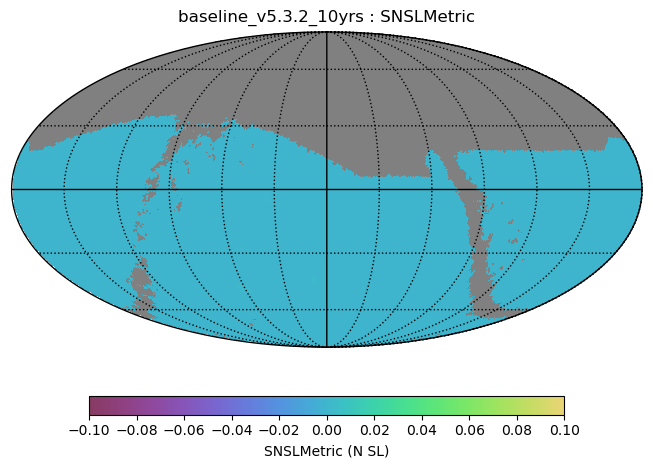

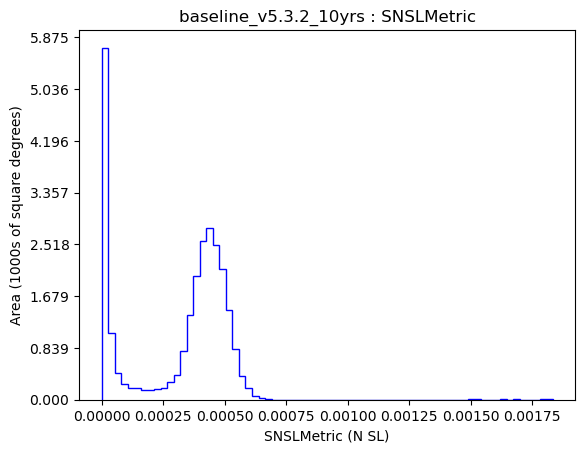

In [4]:
t1 = time.time()
bg.run_all()     
t2 = time.time()
bg.plot_all(closefigs=False)
print('runtime=', t2-t1, 's')


In [5]:
bundle.summary_values

{'Total detected': np.float64(9.825994942957603)}

In [6]:
np.nansum(bundle.metric_values)

np.float64(9.825994942957603)